<h1>Sarcasm detection system using custom
Naïve Bayes implementations</h1>

In [881]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import re
import json
import math 
from collections import defaultdict, Counter
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [882]:
student_ID= 'R00276690'
last_6 =int(student_ID.replace('R00', '')) % 1000000
seed= last_6%100000

In [945]:
df = pd.read_json('Sarcasm_Headlines_Dataset_v2.json', lines=True)
print(df.shape)
df.head()

(28619, 3)


,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


In [884]:
#shuffling
df_shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)
df_shuffled.head()

,is_sarcastic,headline,article_link
0,1,woman walking alone at night picks up pace aft...,https://local.theonion.com/woman-walking-alone...
1,0,exxon mobil told to hand over decades of clima...,https://www.huffingtonpost.com/entry/exxon-mas...
2,0,top german soccer team hit in explosions,https://www.huffingtonpost.com/entry/borussia-...
3,0,assad's forces take 'capital of revolution',https://www.huffingtonpost.com/entry/assad-tak...
4,1,you to receive 15 pounds of venison sausage fr...,https://www.theonion.com/you-to-receive-15-pou...


In [885]:
#70/15/15 split 
n = len(df_shuffled)
training_upper_lim =int(0.7*n)
validation_upper_lim =int(0.85*n)
training_dataset =df_shuffled.iloc[: training_upper_lim]
validation_dataset =df_shuffled.iloc[training_upper_lim:validation_upper_lim]
test_dataset= df_shuffled.iloc[validation_upper_lim:]

In [886]:

print(test_dataset.tail())
print(f'train dataset count: {len(training_dataset)}')
print(f'validation dataset count: {len(validation_dataset)}')
print(f'test dataset count: {len(test_dataset)}')
total = len(training_dataset) + len(validation_dataset) + len(test_dataset)


print(total)
#total and n value same, so data mismatch in count

       is_sarcastic                                           headline  \
28614             0  dog brothers can't get enough of their new duc...   
28615             0                 what i never knew about motherhood   
28616             0  a pastoral letter to older generations about t...   
28617             1  flu vaccine recalled due to defective governme...   
28618             0  kaia gerber, cindy crawford's daughter, lands ...   

                                            article_link  
28614  https://www.huffingtonpost.comhttp://pubx.co/Q...  
28615  https://www.huffingtonpost.com/entry/what-i-ne...  
28616  https://www.huffingtonpost.com/entry/a-pastora...  
28617  https://www.theonion.com/flu-vaccine-recalled-...  
28618  https://www.huffingtonpost.com/entry/cindy-cra...  
train dataset count: 20033
validation dataset count: 4293
test dataset count: 4293
28619


In [887]:
#smoothing
smoothing_sets = {
    0:[0, 0.1, 1],
    1:[0, 0.5, 2],
    2:[0, 1,   5],}
k = seed %4 
smoothing_key= seed % 3
selected_alphas= smoothing_sets[smoothing_key]
print(f'Ablation index, k: {k}')
print(f'selected alphas: {selected_alphas}')

Ablation index, k: 2
selected alphas: [0, 0.5, 2]


**Task 1 – Tokenisation & Preprocessing**

In [941]:
#basic cleaning
def basic_cleaning (text):
    """
    custom function to do the basic cleaninig applying regex, lowercase, tokenisation, html removal etc
    """
    text = text.lower() #to lowercase
    text = re.sub(r"<.*?>","", text) #to remove HTML tags
    text = re.sub(r'[?!]*\?[!]+[?!]*|[?!]*![?]+[?!]*', '[INT_MARK]', text)
    text = re.sub(r'!{2,}','[EXC_SEQ]',  text) #Exclamation Sequences: !!, !!!, etc. >> [EXC_SEQ]
    text = re.sub(r'\?{2,}','[QUE_SEQ]',  text)  #Question Sequences: ??, ???, etc.>>[QUE_SEQ]
    text = re.sub(r'\.{3,}',   '[ELLIP]',    text) #Ellipses:>>[ELLIP]
    text = re.sub(r" '\b|\b' ", " ", text) #Removing all remaining punctuation except apostrophes inside words
    text = re.findall(r'\[.*?\]|\w+(?:\'\w+)*', text) #tokenisation
    return text

     
     

references:
https://www.geeksforgeeks.org/python/how-to-remove-html-tags-from-string-in-python/

https://regex101.com/

https://docs.python.org/3/library/re.html#re.sub #pattern substitution


In [942]:
df_shuffled['headline'].iloc[1]

'exxon mobil told to hand over decades of climate documents in major legal blow'

In [943]:
#testing if regex is working
sample_headlines = [
    "Scientists DISCOVER!!! That Water Is WET!!",   
    "Are? you?? serious????",             
    "Oh reaLly?! come on!!??",      
    "just waiting...",    
    "<b>Breaking news</b>: bomb blast", 
    "senate's new plan to [repeal] but not replace",  
    "a 'damn' letter from a ser'ial killer",    
]

data=[]
for i in sample_headlines:
    word =basic_cleaning(i)
    print(word)




['scientists', 'discover', '[EXC_SEQ]', 'that', 'water', 'is', 'wet', '[EXC_SEQ]']
['are', 'you', '[QUE_SEQ]', 'serious', '[QUE_SEQ]']
['oh', 'really', '[INT_MARK]', 'come', 'on', '[INT_MARK]']
['just', 'waiting', '[ELLIP]']
['breaking', 'news', 'bomb', 'blast']
["senate's", 'new', 'plan', 'to', '[repeal]', 'but', 'not', 'replace']
['a', 'damn', 'letter', 'from', 'a', "ser'ial", 'killer']


**Step 2 – Negation Handling**

In [891]:
#Negation Handling
negation_words={ "not", "no", "never", "don't", "didn't", "isn't", "wasn't"}
stop_words={"the", "a","also","an","and","are","as","at","be","because","been","but",
            "by","for","from","has","have","however","if","in","is","of",
            "on","or","so","than","that","their","there","these","this","to","was","were"}
vowels = set('aeiou')


def negation_handling(tokens):
    """
    prefixes token after A negative word with NOT_
    
    parameter:
    token : list of str
    
    output from basic cleaninig
    return: list of str
    token with NOT_ for relevant tokens
    
    eg:
    input : ['i', 'do', 'not', 'like', 'this']
    output: ['i', 'do', 'not', 'NOT_like', 'this']
    """
    result = []
    i = 0
    while i < len(tokens):
        token = tokens[i]
        if token in negation_words:
            result.append(token)
            n_vowels = sum(1 for char in token if char in vowels)
            i += 1
            for _ in range(n_vowels):
                if i < len(tokens):
                    result.append("NOT_" + tokens[i])
                    i += 1
        else:
            result.append(token)
            i += 1
    return result
    


**Step 3 – Stopword Removal**

In [892]:

def stopword_removal(tokens):
    """
    Remove stopword from token list, exceptNOT_prefixed tokens

    parameters:
    token: list of Str
    tokenised headline after negation handling

    eg:
    input:  ['this', 'is', 'a', 'NOT_good', 'movie']
    output: ['NOT_good', 'movie']
    """
    return [t for t in tokens if t.startswith("NOT_") or t not in stop_words]

test_stp_rmvl =["this","is","a","NOT_good","movie"]
print(f'before : {test_stp_rmvl}')
new_rmvl =stopword_removal(test_stp_rmvl)
print(f"after : {new_rmvl}")




before : ['this', 'is', 'a', 'NOT_good', 'movie']
after : ['NOT_good', 'movie']


**Step 4 – Generate N-grams**

In [893]:
def generate_ngrams(tokens):
    """
    generate unigram and bigrams form tokenlist

    parameter:

    tokens : list of str
     cleaned token list

     eg:

     input :
     ["this","is","a","NOT_good","movie"]

    output:
    ['this', 'is', 'a', 'NOT_good', 'movie', 'this__is', 'is__a', 'a__NOT_good', 'NOT_good__movie']

    """
    unigrams =tokens
    bigrams= [f"{tokens[i]}__{tokens[i+1]}" for i in range(len(tokens) - 1)]
    return unigrams + bigrams

    
test_ngrams = generate_ngrams(test_stp_rmvl)
print(test_ngrams)

['this', 'is', 'a', 'NOT_good', 'movie', 'this__is', 'is__a', 'a__NOT_good', 'NOT_good__movie']


**Step 5 – OOV Handling**

In [894]:
def replace_oov(tokens, vocab):
    return [t if t in vocab else "<UNK>" for t in tokens]

In [895]:
#preprocessing pipeline
def preprocess(text, vocab=None):
    """
    To pre process a given string into tokens suitable for NLP tasks
    
    parameters:
    text: Str 
      news headline
    vocab: set , optional
    
    """
    tokens =basic_cleaning(text) #basic cleaning
    tokens= negation_handling(tokens) #negation handling
    tokens= stopword_removal(tokens) #stopword removal
    all_tokens =generate_ngrams(tokens) #generate n_grams
    if vocab is not None:
        all_tokens =replace_oov(all_tokens, vocab)
    return all_tokens

In [896]:
text = "I do not like this movie"
new_sam = preprocess(text)
print(f'after preprocessing: {new_sam}')

after preprocessing: ['i', 'do', 'not', 'NOT_like', 'movie', 'i__do', 'do__not', 'not__NOT_like', 'NOT_like__movie']


In [897]:
#OOV Handling and vocabulary building
train_tokens = training_dataset["headline"].apply(preprocess)
vocab= set(tkn for doc in train_tokens for tkn in doc)
train_tokens = training_dataset["headline"].apply(lambda x: preprocess(x, vocab))
val_tokens = validation_dataset["headline"].apply(lambda x: preprocess(x, vocab))
test_tokens = test_dataset["headline"].apply(lambda x: preprocess(x, vocab))

In [898]:
val_tokens.head()


20033    [two, non, binary, college, activists, creatin...
20034    [jill, <UNK>, saw, <UNK>, singer's, divorce, c...
20035    [study, major, shift, media, landscape, occurs...
20036    [new, healthier, menu, features, food, wendy's...
20037    [bob, dole, picked, off, large, hawk, circling...
Name: headline, dtype: object

In [899]:
test_tokens.head()

24326    [wildfires, force, colorado, <UNK>, rocky, mou...
24327    [best, chance, defeat, roy, moore, may, democr...
24328                          [pentagon, planning, <UNK>]
24329    [no, NOT_more, adult, conversations, prayers, ...
24330    [alabama, native, channing, tatum, encourages,...
Name: headline, dtype: object

In [900]:
train_tokens.head()

0    [woman, walking, alone, night, picks, up, pace...
1    [exxon, mobil, told, hand, over, decades, clim...
2    [top, german, soccer, team, hit, explosions, t...
3    [assad's, forces, take, capital, revolution, a...
4    [you, receive, 15, pounds, venison, sausage, u...
Name: headline, dtype: object

<h1>Task 2 – Manual Feature Representation</h1>

In [901]:
#Compute Document Frequency for each token

#count vectoriser
def compute_doc_freq(tokenised_doc):
    """
    count how many times each token appears

    parameters:
    input:
    tokenised_doc : list of list of str

    output:
     distionary of all token

     eg:
     input >> [['what', 'sat'], ['what', 'ran']]
     output >> {'cat': 2, 'sat': 1, 'ran': 1}
    
    """
    doc_freq_count ={}
    for doc in tokenised_doc:
        for tkn in set(doc): #to remove the duplicates
            doc_freq_count[tkn]= doc_freq_count.get(tkn,0) + 1

    return doc_freq_count
doc_freq_count = compute_doc_freq(train_tokens.tolist())

#print(doc_freq_count)

In [902]:
#Rare Word Filtering
#Count Vectoriser
t = (seed % 6) + 2 #this clean up the noise, any word appearing less than t value will be removed
print(f"seed={seed}")
print(f"seed mod 6={seed % 6}")
print(f"threshold ={t}")

seed=76690
seed mod 6=4
threshold =6


In [903]:
#sorting in alphabetical order
filtered_tokens = [token for token, count in doc_freq_count.items() if count >= t]
filtered_tokens = sorted(filtered_tokens)
#print(filtered_tokens)

In [904]:
#prime position indexing
def find_prime_number(n):
    """
    map token that appear on prime position to sepearte feature colomn
    parameter:
    n : list of Str
    token

    eg:
     input:  filtered_tokens = ["i", "love", "ai", "not", "good", "movie"]
     output:
     primes_list      # {2, 3, 5, 7, 11, 13}
    """
    prime_list =[True]* (n+1)
    prime_list[0]=False
    prime_list[1]=False
    for i in range(2, int(n**0.5)+1):
        if prime_list[i]:
            for j in range(i*i,n+1,i):
                prime_list[j]=False
    return {i for i in range(2,n+1) if prime_list[i]}


In [905]:
primes_list = find_prime_number(len(filtered_tokens) +10) #buffer added just in case

feature_map = {0: "NON_PRIME"} # colomn 0 is always not prime
for position, token in enumerate(filtered_tokens,start=1):
    if position in primes_list:
        feature_map[position] =token #seperate  colomns for prime number
colomn_order = sorted(feature_map.keys())
prime_positions = set(feature_map.keys()) - {0} #since 0 is already non prime
token_matrix = {tkn: pos for pos,tkn in enumerate(filtered_tokens,start=1)}

In [906]:
def build_count_matrix(tokenised_docs):
    """
    Building a count matrix for document based on prime position indexing\

    Parameter: 
    tokenised_docs: List of List of Str

    returns:
    2D np array
    """
    rows=[]
    for doc in tokenised_docs:
        counts = {}
        for token in doc:
            pos=token_matrix.get(token)
            if pos is None:
                continue
            if pos in prime_positions:
                counts[pos]=counts.get(pos,0) +1
            else:
                counts[0] = counts.get(0,0) +1
        rows.append([counts.get(c,0) for c in colomn_order])
    return np.array(rows)


In [907]:
train_data_matrix = build_count_matrix(train_tokens.tolist())
test_data_matrix = build_count_matrix(test_tokens.tolist())
validation_data_matrix = build_count_matrix(val_tokens.tolist())


In [908]:
print(f"train_count: {train_data_matrix.shape}")
print(f"val_count: {validation_data_matrix.shape}")
print(f"test_count: {test_data_matrix.shape}")

train_count: (20033, 791)
val_count: (4293, 791)
test_count: (4293, 791)


**B. TF-IDF**

In [909]:
#Computing term frequency for a single document.
def compute_tf(doc):
    """
    compute term frequency for single document
    tf = unt of token in document / total token in doc

    parameters:
    doc : list of str
    tokenised document

    return dict
    {token : tf score}

    eg:

    {alabama__lawmakers: 10.2120}
    """
    tf ={}
    total_words = len(doc) if len(doc) > 0 else 1
    for tkn in doc :
        tf[tkn]= tf.get(tkn,0) +1
    for tkn in tf:
        tf[tkn] = tf[tkn]/total_words
    return tf

#Computing IDF for all tokens.
def compute_idf(df_count, n):
    idf ={}
    for tkn,doc_freq in df_count.items():
        idf[tkn]=math.log((n+1)/(doc_freq+1)) +1
    return idf

num_train_docs = len(training_dataset)
idf = compute_idf(doc_freq_count, num_train_docs)
sample_words = list(idf.items())[:5]
for word, score in sample_words:
    print(f"  '{word}' => IDF = {score:.4f}")

  'after' => IDF = 4.3527
  'truck__full' => IDF = 10.2120
  'woman' => IDF = 5.0473
  'alabama__lawmakers' => IDF = 10.2120
  'full' => IDF = 6.6285


In [910]:
def compute_tf_idf(tokenised_docs, idf, filtered_tokens):
    """
    to compute TF-IDF vectors for a list of tokenized documents
    Parameter:

    tokenised_docs : list of list of str
        tokenised document
    idf : dict

    filtered_tokens : list of Str

    Output:
    2d array of document represent row and col represnt tdf-idf score of token
    """
    tkn_index = {t: i for i, t in enumerate(filtered_tokens)}
    rows = []
    for doc in tokenised_docs:
        vct = np.zeros(len(filtered_tokens))
        tf  = compute_tf(doc)
        for tkn, tf_score in tf.items():
            if tkn in tkn_index:     
                index = tkn_index[tkn]
                idf_score = idf.get(tkn, 0)
                vct[index] = tf_score * idf_score
        rows.append(vct)
    return np.array(rows)

# TF-IDF
train_tf_idf= compute_tf_idf(train_tokens.tolist(), idf, doc_freq_count)
val_tf_idf= compute_tf_idf(val_tokens.tolist(),idf, doc_freq_count)
test_tf_idf= compute_tf_idf(test_tokens.tolist(),  idf, doc_freq_count)

print(f"{train_tf_idf.shape}")
print(f"tfidf matrix:{train_tf_idf[0][:10].round(4)}")


(20033, 145998)
tfidf matrix:[0.1404 0.3294 0.1628 0.3294 0.2138 0.2551 0.1666 0.2312 0.2809 0.2536]


**C. Using the training dataset, report the top 10 tokens with the highest Document**

In [911]:
top10 = sorted(doc_freq_count.items(), key=lambda x: -x[1])[:10]
top10_df =pd.DataFrame(top10, columns=['Token', 'Document Frequency'])
print(top10_df.to_string(index=False))


Token  Document Frequency
 with                1370
  new                1148
trump                1021
  man                 955
about                 766
  you                 701
after                 700
   up                 651
  out                 630
   it                 585


<h1> Task 3 — Naive Bayes Variants</h1>

**A. Multinomial NB**

In [912]:
train_y = training_dataset['is_sarcastic'].values
y_val = validation_dataset['is_sarcastic'].values
y_test = test_dataset['is_sarcastic'].values

def evaluate(y_true, y_pred, label=''):
    """
    create classitifiction matrix for a set of predictions

    parameter:
    y_true: np.ndarray
    true label

    y_pred : str
    redicted label

    return:
    tuple of accuracy,f1,f1_sarcasm
    """
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)
    f1m = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    print(f'{label} Accuracy={acc:.4f} F1={f1:.4f} F1-sarc={f1m:.4f}')
    return acc, f1, f1m


In [913]:
def train_multinomial_nb(train_x, val_x, train_y, y_val, alphas):
    """
    Train multi nomial naive classifier and selects best smoothing aipha

    parameter:
    train_x : np.ndarray, shape (n_train, n_features)
    training count matrix

    val_x: np.ndarray, shape (n_val, n_features) 
    validation count matrix
    
    train_y :np.ndarray()
    training label0/1
    
    y_val: np.ndarray()
    validation label 0/1

    alphas: list of float
    smoothing values

    returns:
    tuple of (np.ndarray, np.ndarray, float, float)
    best ll_non_sarc: log-likelihoods for not-sarcastic class, shape (n_features,)
    best ll_sarc: log-likelihoods for sarcastic class, shape (n_features,)
    p_non_sarc_log: log prior for not-sarcastic class
    p_sarc_log: log prior for sarcastic class
    
    """
    p_non_sarc = np.mean(train_y==0)
    p_sarc = np.mean(train_y == 1)
    p_non_sarc_log = np.log(p_non_sarc)
    p_sarc_log = np.log(p_sarc)
    
    best_alpha = None
    best_f1=-1
    best_ll_non_sarc= None
    best_ll_sarc = None,
    
    for alpha in alphas:
        num_features = train_x.shape[1] 
        
        if alpha == 0:
            alpha = 1e-10 
        
        #non sarcasm class
        non_sarc_matrix = train_x[train_y == 0] #boolean indexing- only non sarcastic
        counts_non_sarc = non_sarc_matrix.sum(axis=0) 
        total_non_sarc  = counts_non_sarc.sum()
        ll_non_sarc = np.log( (counts_non_sarc + alpha) / (total_non_sarc + alpha * num_features) )
        
        #sarcasm class  
        sarc_matrix = train_x[train_y == 1] 
        counts_sarc = sarc_matrix.sum(axis=0)
        total_sarc  = counts_sarc.sum()
        ll_sarc = np.log( (counts_sarc + alpha) / (total_sarc + alpha * num_features) )
        
        #Validation predictions
        scores_non_sarc = p_non_sarc_log + val_x @ ll_non_sarc
        scores_sarc = p_sarc_log + val_x @ ll_sarc 
        y_pred = (scores_sarc > scores_non_sarc).astype(int) #predicts whichever class scores higher
        
        acc, f1, f1m = evaluate(y_val, y_pred, f'alpha={alpha}')
        #f1 better compared to accuracy since our data is imbalanced
        if f1 > best_f1:
            best_f1 = f1
            best_alpha = alpha
            best_ll_non_sarc = ll_non_sarc
            best_ll_sarc = ll_sarc
    
    return best_ll_non_sarc, best_ll_sarc, p_non_sarc_log, p_sarc_log

ll_non_sarc, ll_sarc, p_non_sarc_log, p_sarc_log = train_multinomial_nb(train_data_matrix,validation_data_matrix,train_y,y_val,selected_alphas)

# Test
test_scores_non_sarc = p_non_sarc_log + test_data_matrix @ ll_non_sarc
test_scores_sarc = p_sarc_log + test_data_matrix @ ll_sarc
y_test_pred = (test_scores_sarc > test_scores_non_sarc).astype(int)


evaluate(y_test, y_test_pred, 'Multinomial NB Test')



alpha=1e-10 Accuracy=0.6215 F1=0.6040 F1-sarc=0.5208
alpha=0.5 Accuracy=0.6224 F1=0.6047 F1-sarc=0.5211
alpha=2 Accuracy=0.6212 F1=0.6032 F1-sarc=0.5187
Multinomial NB Test Accuracy=0.6152 F1=0.5956 F1-sarc=0.5066


(0.6151875145585838, 0.595591767357647, 0.5065710872162486)

**B. Bernoulli NB**

In [914]:
train_binary =(train_data_matrix > 0).astype(int)
val_binary =(validation_data_matrix > 0).astype(int)
test_binary =(test_data_matrix > 0).astype(int)

p_non_sarc = np.mean(train_y==0)
p_sarc = np.mean(train_y == 1)
p_non_sarc_log = np.log(p_non_sarc)
p_sarc_log = np.log(p_sarc)

In [915]:
best_alpha_bern=None
best_f1_bern = -1
best_ll_non_sarc_bern= None
best_ll_sarc_bern = None

for alpha in selected_alphas:
    num_features = train_binary.shape[1]
    if alpha == 0:
        alpha = 1e-10 #0 causing error, so assigned a smaller value

    #non sarcasm
    non_sarc_matrix = train_binary[train_y == 0] #Non-sarcasm: P(word present | non-sarcastic)
    present_non_sarc = non_sarc_matrix.sum(axis=0) #docs containing each word
    docs_non_sarc = non_sarc_matrix.shape[0] #number of rows in matrix
    ll_non_sarc = np.log( (present_non_sarc + alpha) / (docs_non_sarc + 2*alpha) )
    
    #sarcasm
    sarc_matrix = train_binary[train_y == 1]
    present_sarc = sarc_matrix.sum(axis=0)
    docs_sarc = sarc_matrix.shape[0]
    ll_sarc = np.log( (present_sarc + alpha) / (docs_sarc + 2*alpha) )
    
    ll_absent_non_sarc = np.log(1 - np.exp(ll_non_sarc))
    ll_absent_sarc = np.log(1 - np.exp(ll_sarc))
    
    # Validation: present*ll_present + abscent*ll_abscent
    scores_non_sarc =(p_non_sarc_log + val_binary@ll_non_sarc + (1-val_binary)@ll_absent_non_sarc)
    
    scores_sarc =(p_sarc_log + val_binary@ll_sarc + (1-val_binary)@ll_absent_sarc)
    
    y_pred = (scores_sarc >scores_non_sarc).astype(int) #predicts which class is higher
    
    acc,f1,f1m = evaluate(y_val, y_pred, f'alpha={alpha}')
    
    if f1 > best_f1_bern:
        best_f1_bern = f1
        best_alpha_bern = alpha
        best_ll_non_sarc_bern =(ll_non_sarc, ll_absent_non_sarc)
        best_ll_sarc_bern = (ll_sarc, ll_absent_sarc)

alpha=1e-10 Accuracy=0.6189 F1=0.6022 F1-sarc=0.5205
alpha=0.5 Accuracy=0.6203 F1=0.6036 F1-sarc=0.5223
alpha=2 Accuracy=0.6196 F1=0.6021 F1-sarc=0.5187


In [916]:
#testing best model
(ll_non_sarc_bern, ll_absent_non_bern) = best_ll_non_sarc_bern #ll_absent_non_bern -tkn that doesn't show up in headline
(ll_sarc_bern, ll_absent_sarc_bern) = best_ll_sarc_bern

test_scores_non_sarc = (p_non_sarc_log + test_binary @ ll_non_sarc_bern + (1-test_binary) @ ll_absent_non_bern)
test_scores_sarc = (p_sarc_log + test_binary @ ll_sarc_bern + (1-test_binary) @ ll_absent_sarc_bern)
y_test_pred_bern = (test_scores_sarc > test_scores_non_sarc).astype(int)
evaluate(y_test, y_test_pred_bern, 'Bernoulli NB Test')

Bernoulli NB Test Accuracy=0.6157 F1=0.5969 F1-sarc=0.5101


(0.6156533892382949, 0.5969409517029031, 0.5100950118764845)

<h1>Numeric Feature Engineering</h1>

<h1>Task 4 – Numeric Meta-Features & Imputation</h1>

In [917]:
def extract_num_features(df):
    """
    extract numerical feature from raw headline
    parameter:
    df : pd.dataframe
    headline line colomn with headline strings
    returns: pd.dataframe
    word_count  - number of words (split on whitespace)
    char_len    - total character length of headline
    upper_count - number of fully uppercase words
    excl_count  - number of exclamation marks
    ques_count  - number of question marks
    neg_count   - number of negation words
    digit_count - number of digit characters
    sarc_ratio  - upper_count / word_count, 
    
    """
    num_features = pd.DataFrame(index=df.index)
    num_features['word_count'] = df['headline'].str.split().str.len()
    num_features['char_len'] = df['headline'].str.len()
    num_features['upper_count'] = df['headline'].str.count(r'\b[A-Z]+\b')
    num_features['excl_count'] = df['headline'].str.count('!')
    num_features['ques_count'] = df['headline'].str.count(r'\?')
    num_features['neg_count'] = df['headline'].str.lower().str.count('|'.join(negation_words))
    num_features['digit_count'] = df['headline'].str.count(r'\d')
    num_features['sarc_ratio'] = np.where( num_features['word_count'] > 0,num_features['upper_count'] / num_features['word_count'],0.5) # Sarcasm ratio
    
    return num_features
    

train_features = extract_num_features(training_dataset)
val_features = extract_num_features(validation_dataset)
test_features = extract_num_features(test_dataset)

**A. Inject Missing Values**

In [918]:
def inject_missing(df, missing_rate=0.05):
    df  = df.copy().astype(float)
    rand_num_gen = np.random.default_rng(seed) 
    total_cells = df.shape[0] * df.shape[1]
    num_missing   = int(total_cells * missing_rate) #calculation for 5% total
    forced_row = int(rand_num_gen.integers(0, len(df))) #pick a random row number
    df.iat[forced_row, df.columns.get_loc('sarc_ratio')] = np.nan #set that colomn to NaN
    num_missing -= 1 

    all_cells = [
        (r, c)
        for r in range(df.shape[0])
        for c in range(df.shape[1])
    ]

    chosen = rand_num_gen.choice(len(all_cells), size=num_missing, replace=False)
    #loop through row and colomn to set the cell to NaN
    for idx in chosen:
        r, c = all_cells[idx]
        df.iat[r, c] = np.nan      
    return df

train_features_miss = inject_missing(train_features.copy())
val_features_miss = inject_missing(val_features.copy())
test_features_miss = inject_missing(test_features.copy())
print(train_features_miss.isna().sum())

word_count     1012
char_len        952
upper_count    1007
excl_count     1001
ques_count      996
neg_count      1015
digit_count     986
sarc_ratio     1044
dtype: int64


**B. Handle Missing Values**

In [919]:
#mean imputation
train_mean = train_features_miss.mean()
train_mean_imp= train_features_miss.fillna(train_mean)
val_mean_imp= val_features_miss.fillna(train_mean)
test_mean_imp= test_features_miss.fillna(train_mean)

#training model_ on mean imputed data
ll_non_sarc_mean, ll_sarc_mean, p_nonsarc_log_mean, p_sarc_log_mean = train_multinomial_nb(
    train_mean_imp, val_mean_imp, train_y, y_val, selected_alphas
)

test_scores_ns_mean= p_nonsarc_log_mean + test_mean_imp@ ll_non_sarc_mean
test_scores_s_mean= p_sarc_log_mean+ test_mean_imp@ ll_sarc_mean
y_test_pred_mean= (test_scores_s_mean > test_scores_ns_mean).astype(int)

evaluate(y_test, y_test_pred_mean, 'Global Mean Imputation')


# class conditional mean imputation
train_mean_non_sarc = train_features_miss[train_y == 0].mean()
train_mean_sarc = train_features_miss[train_y == 1].mean()
class_mean_imp = train_features_miss.copy()
class_mean_imp.loc[train_y == 0] = class_mean_imp.loc[train_y == 0].fillna(train_mean_non_sarc)
class_mean_imp.loc[train_y == 1] = class_mean_imp.loc[train_y == 1].fillna(train_mean_sarc)


val_class_imp = val_features_miss.fillna(train_mean)
test_class_imp = test_features_miss.fillna(train_mean)

#training model _ class imputed  
ll_ns_class, ll_s_class, p_ns_log_class, p_s_log_class = train_multinomial_nb(
    class_mean_imp, val_class_imp, train_y, y_val, selected_alphas
)
#prediction
test_scores_ns_class = p_ns_log_class + test_class_imp@ll_ns_class
test_scores_s_class = p_s_log_class  + test_class_imp@ll_s_class
y_test_pred_class = (test_scores_s_class > test_scores_ns_class).astype(int)

evaluate(y_test, y_test_pred_class, 'Class Mean Imputation')

alpha=1e-10 Accuracy=0.5427 F1=0.4967 F1-sarc=0.3446
alpha=0.5 Accuracy=0.5427 F1=0.4967 F1-sarc=0.3446
alpha=2 Accuracy=0.5427 F1=0.4967 F1-sarc=0.3446
Global Mean Imputation Accuracy=0.5577 F1=0.5178 F1-sarc=0.3792
alpha=1e-10 Accuracy=0.5420 F1=0.5006 F1-sarc=0.3567
alpha=0.5 Accuracy=0.5420 F1=0.5006 F1-sarc=0.3567
alpha=2 Accuracy=0.5418 F1=0.5004 F1-sarc=0.3566
Class Mean Imputation Accuracy=0.5595 F1=0.5255 F1-sarc=0.3983


(0.5595154903331004, 0.5254634134137324, 0.3983455297486478)

In [920]:
#write comparison code here

<h1>Task 5 – Outlier Detection</h1>

**A. Detect Outliers**

In [921]:
def detect_outliers_iqr(X, factor=1.5):
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - factor*IQR
    upper_fence = Q3 + factor*IQR
    outliers = ((X < lower_fence)|(X > upper_fence)).any(axis=1) #collapsing very row into single T/F
    print(f"Outliers: {outliers.sum()} out of {len(X)} ,percentage:({outliers.mean()*100:.1f}%)")
    return outliers, lower_fence, upper_fence

outlier_train, lower_fence, upper_fence = detect_outliers_iqr(class_mean_imp) #class mean imputed data


Outliers: 9030 out of 20033 ,percentage:(45.1%)


**B. Treat Outliers**

In [922]:
print("\nOutliers by class:")
outlier_labels = pd.Series(train_y[outlier_train])
print(outlier_labels.value_counts(normalize=True))

# Clamp values to boundary
X_train_clamped = class_mean_imp.clip(lower=lower_fence, upper=upper_fence, axis=1) #numeric data frame
X_val_clamped = val_class_imp.clip(lower=lower_fence, upper=upper_fence, axis=1)
X_test_clamped = test_class_imp.clip(lower=lower_fence, upper=upper_fence, axis=1)



Outliers by class:
0    0.52979
1    0.47021
Name: proportion, dtype: float64


In [923]:
class_dist = pd.Series(train_y).value_counts(normalize=True)
print(class_dist)

0    0.52703
1    0.47297
Name: proportion, dtype: float64


In [924]:
#non sarcastic 0
#sarcastic 1

**performace report and class distribution after clamping**

In [925]:
#gaussian naive bias 
def gaussian_nb(train_x, train_y, test_x):
    """
    trains and predict using gauisan naive bayes on numericfeatures 
    """
    log_prior_non_sarc = np.log(np.mean(train_y == 0))
    log_prior_sarc     = np.log(np.mean(train_y == 1))
    rows_non_sarc = train_x[train_y == 0]
    rows_sarc = train_x[train_y == 1]

    mean_non_sarc = rows_non_sarc.mean(axis=0)
    mean_sarc = rows_sarc.mean(axis=0)
    var_non_sarc = rows_non_sarc.var(axis=0) + 1e-10 #added a buffer term since it is used in division
    var_sarc = rows_sarc.var(axis=0) + 1e-10

    #prediction
    spread_non_sarc = np.log(2 * np.pi * var_non_sarc)
    distance_non_sarc = ((test_x - mean_non_sarc) ** 2) / var_non_sarc
    score_non_sarc = log_prior_non_sarc + (-0.5 * np.sum(spread_non_sarc + distance_non_sarc, axis=1))
    spread_sarc = np.log(2 * np.pi * var_sarc)
    distance_sarc = ((test_x - mean_sarc) ** 2) / var_sarc
    score_sarc = log_prior_sarc + (-0.5 * np.sum(spread_sarc + distance_sarc, axis=1))

    return (score_sarc > score_non_sarc).astype(int)

In [926]:
#with outliers
y_test_base  = gaussian_nb(class_mean_imp.values,  train_y, test_class_imp.values)
evaluate(y_test, y_test_base,'with outliers')

#with IQR clamping
y_test_clamp = gaussian_nb(X_train_clamped.values, train_y, X_test_clamped.values)
evaluate(y_test, y_test_clamp,'with IQR clamping')

with outliers Accuracy=0.5115 F1=0.3881 F1-sarc=0.6629
with IQR clamping Accuracy=0.5693 F1=0.5409 F1-sarc=0.4267


(0.5692988586070347, 0.5408841634023503, 0.4266666666666667)

In [927]:
print(class_mean_imp.describe().round(2))
print(X_train_clamped.describe().round(2))


       word_count  char_len  upper_count  excl_count  ques_count  neg_count  \
count    20033.00  20033.00      20033.0    20033.00    20033.00   20033.00   
mean        10.04     62.26          0.0        0.01        0.03       0.18   
std          3.34     20.55          0.0        0.08        0.17       0.42   
min          2.00      7.00          0.0        0.00        0.00       0.00   
25%          8.00     49.00          0.0        0.00        0.00       0.00   
50%         10.00     62.00          0.0        0.00        0.00       0.00   
75%         12.00     74.00          0.0        0.00        0.00       0.00   
max        151.00    926.00          0.0        3.00        2.00       4.00   

       digit_count  sarc_ratio  
count     20033.00     20033.0  
mean          0.35         0.0  
std           0.99         0.0  
min           0.00         0.0  
25%           0.00         0.0  
50%           0.00         0.0  
75%           0.00         0.0  
max          12.00      

In [928]:
before_counts = pd.Series(train_y).value_counts().sort_index()
after_counts  = pd.Series(train_y[~outlier_train]).value_counts().sort_index() 
print(f"{'Class 0: Not Sarcastic':} {before_counts[0]:} {before_counts[0]:}")
print(f"{'Class 1: Sarcastic':} {before_counts[1]:} {before_counts[1]:}")
print(f"{'Total rows':} {len(train_y):} {len(train_y):}")

Class 0: Not Sarcastic 10558 10558
Class 1: Sarcastic 9475 9475
Total rows 20033 20033


<h1>Task 6 – Scaling Study</h1>

In [929]:
#min-max scaling
def minmax_scale(train_x, val_x, test_x):
    x_min = train_x.min(axis=0)
    x_max = train_x.max(axis=0)
    x_range = x_max - x_min 
    return ((train_x - x_min)/x_range,
        (val_x - x_min)/x_range,
        (test_x - x_min)/x_range)

#standardisation
def standardize(train_x,val_x,test_x):
    x_mean = train_x.mean(axis=0)
    x_std  = train_x.std(axis=0)
    x_std[x_std == 0] = 1 #to avoid division by zero
    return (
        (train_x - x_mean)/ x_std,
        (val_x - x_mean)/x_std,
        (test_x - x_mean)/x_std
    )

In [930]:
X_train_scale = X_train_clamped.values.copy()
X_val_scale = X_val_clamped.values.copy()  
X_test_scale = X_test_clamped.values.copy()

In [931]:
#no scaling
y_test_pred_raw = gaussian_nb(X_train_scale, train_y, X_test_scale)
acc_raw, f1_raw, f1m_raw = evaluate(y_test, y_test_pred_raw,'NO scaling')

#minmax scaling
X_train_minmax, X_val_minmax, X_test_minmax = minmax_scale(X_train_scale, X_val_scale, X_test_scale)
y_test_pred_minmax = gaussian_nb(X_train_minmax, train_y, X_test_minmax)
acc_minmax, f1_minmax, f1m_minmax = evaluate(y_test, y_test_pred_minmax,'MinMax')

#standardisation
X_train_standard, X_val_standard, X_test_standard = standardize(X_train_scale, X_val_scale, X_test_scale)
y_test_pred_std = gaussian_nb(X_train_standard, train_y, X_test_standard)
acc_std, f1_std, f1m_std = evaluate(y_test, y_test_pred_std,'Standardised')

NO scaling Accuracy=0.5693 F1=0.5409 F1-sarc=0.4267
MinMax Accuracy=0.5155 F1=0.3401 F1-sarc=0.0000
Standardised Accuracy=0.5693 F1=0.5409 F1-sarc=0.4267


/var/folders/dg/72q0h6ss3xq0zf641p8b9gnm0000gn/T/ipykernel_3129/254741689.py:6: RuntimeWarning: invalid value encountered in divide
  return ((train_x - x_min)/x_range,
/var/folders/dg/72q0h6ss3xq0zf641p8b9gnm0000gn/T/ipykernel_3129/254741689.py:7: RuntimeWarning: invalid value encountered in divide
  (val_x - x_min)/x_range,
/var/folders/dg/72q0h6ss3xq0zf641p8b9gnm0000gn/T/ipykernel_3129/254741689.py:8: RuntimeWarning: invalid value encountered in divide
  (test_x - x_min)/x_range)


In [932]:
#every value remain same - no changes , scaling and normalisation has no effect on accuracy

In [933]:
#scling comparison
comparison_data = {
    'Method':['NO scaling','MinMax','Standardised'],
    'Accuracy' :[f'{acc_raw:.4f}',f'{acc_minmax:.4f}', f'{acc_std:.4f}'],
    'F1-macro': [f'{f1_raw:.4f}', f'{f1_minmax:.4f}', f'{f1_std:.4f}'],
    'F1-sarc': [f'{f1m_raw:.4f}', f'{f1m_minmax:.4f}', f'{f1m_std:.4f}']
}

comp_df = pd.DataFrame(comparison_data)
print(comp_df)

         Method Accuracy F1-macro F1-sarc
0    NO scaling   0.5693   0.5409  0.4267
1        MinMax   0.5155   0.3401  0.0000
2  Standardised   0.5693   0.5409  0.4267


<h1>Task 7 – Class Imbalance & Performance Evaluation</h1>

**A. Measure imbalance**

Class 0 non sarcastic:10558
Class 1 sarcastic:9475
Imbalance ratio:1.114


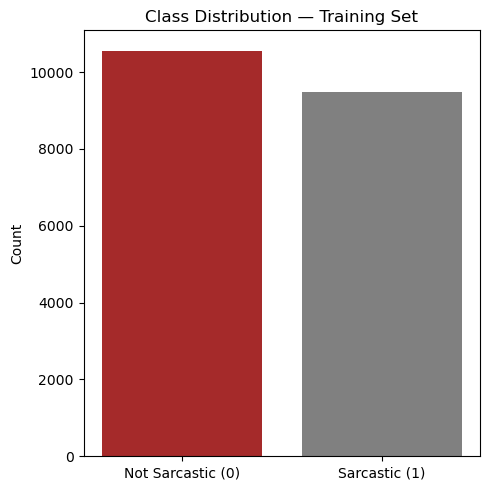

In [934]:
counts = np.bincount(train_y) #return how many time each value appear
print(f'Class 0 non sarcastic:{counts[0]}')
print(f'Class 1 sarcastic:{counts[1]}')
print(f'Imbalance ratio:{counts[0]/counts[1]:.3f}')

plt.figure(figsize=(5,5))
plt.bar(['Not Sarcastic (0)','Sarcastic (1)'], counts, color=['brown', 'grey'])
plt.title('Class Distribution — Training Set')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**B. Random oversampling**

In [935]:
rng_oversample = np.random.default_rng(seed)

def random_oversample(train_x, train_y, rng):
    sarc_class = 1
    non_sarc_class = 0
    sarc_idx= np.where(train_y==sarc_class)[0]
    non_sarc_idx = np.where(train_y==non_sarc_class)[0]
    num_sarc_class = len(sarc_idx)
    num_non_sarc_class = len(non_sarc_idx)
    extra_sample_needed = num_non_sarc_class-num_sarc_class
    print(f'extra_sample_needed: {extra_sample_needed}')
    extra_idx =rng.choice(sarc_idx, size=extra_sample_needed ,replace=True)
    X_minority_extra = train_x[extra_idx]
    y_minority_extra = train_y[extra_idx]
    X_balanced= np.vstack([train_x, X_minority_extra])
    y_balanced =np.concatenate([train_y, y_minority_extra])
    
    #shuffling classes
    order = rng.permutation(len(y_balanced))
    return X_balanced[order], y_balanced[order]



#random oversampling - standardised training data
X_train_balanced, y_train_balanced = random_oversample(X_train_standard, train_y, rng_oversample)

print('Before oversampling:', np.bincount(train_y))
print('After  oversampling:', np.bincount(y_train_balanced))

extra_sample_needed: 1083
Before oversampling: [10558  9475]
After  oversampling: [10558 10558]


**C. Threshold tuning**

In [936]:
#gaussian nb on balanced over sampled data
y_train_balanced_pred = gaussian_nb(X_train_balanced, y_train_balanced, X_val_standard)
rows_non_sarc_os = X_train_balanced[y_train_balanced==0]
rows_sarc_os = X_train_balanced[y_train_balanced==1]

log_prior_non_sarc_os = np.log(np.mean(y_train_balanced==0))
log_prior_sarc_os = np.log(np.mean(y_train_balanced==1))

mean_non_sarc_os= rows_non_sarc_os.mean(axis=0)
mean_sarc_os= rows_sarc_os.mean(axis=0)
var_non_sarc_os= rows_non_sarc_os.var(axis=0) + 1e-10
var_sarc_os= rows_sarc_os.var(axis=0)+ 1e-10


spread_non_sarc_os = np.log(2*np.pi*var_non_sarc_os)
distance_non_sarc_os= ((X_val_standard - mean_non_sarc_os)** 2)/var_non_sarc_os
score_non_sarc_os = log_prior_non_sarc_os +(-0.5 * np.sum(spread_non_sarc_os+distance_non_sarc_os, axis=1))

spread_sarc_os = np.log(2 * np.pi * var_sarc_os)
distance_sarc_os = ((X_val_standard - mean_sarc_os) ** 2)/var_sarc_os
score_sarc_os = log_prior_sarc_os + (-0.5 * np.sum(spread_sarc_os + distance_sarc_os, axis=1))

log_diff= score_sarc_os-score_non_sarc_os
val_proba_sarc= 1/(1 + np.exp(-log_diff))


best_thresh = 0.5
best_f1_thresh = -1

for thresh in np.arange(0.3, 0.75, 0.05):
    y_val_pred_thresh = (val_proba_sarc >= thresh).astype(int)
    f1 = f1_score(y_val, y_val_pred_thresh, average='macro', zero_division=0)
    if f1 > best_f1_thresh:
        best_f1_thresh = f1
        best_thresh= thresh

print(f'best threshold:{best_thresh:.2f}')
print(f'best val F1: {best_f1_thresh:.4f}')

y_val_pred = (val_proba_sarc >= best_thresh).astype(int)

best threshold:0.50
best val F1: 0.5519


**Model evaluation _ confusion matrix**

Confusion Matrix: [[1655  559]
 [1287  792]]
Accuracy: 0.5700
Precision(macro): 0.5744
Recall(macro): 0.5642
F1 macro: 0.5519
F1 minority(sarc): 0.4618


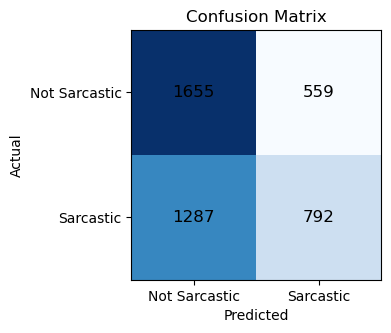

In [937]:
conf_mat = confusion_matrix(y_val, y_val_pred)
print(f'Confusion Matrix: {conf_mat}')
print(f'Accuracy: {accuracy_score(y_val, y_val_pred):.4f}')
print(f'Precision(macro): {precision_score(y_val, y_val_pred, average="macro", zero_division=0):.4f}')
print(f'Recall(macro): {recall_score(y_val, y_val_pred, average="macro", zero_division=0):.4f}')
print(f'F1 macro: {f1_score(y_val, y_val_pred, average="macro", zero_division=0):.4f}') #macro combine score from both classes
print(f'F1 minority(sarc): {f1_score(y_val, y_val_pred, pos_label=1, average="binary", zero_division=0):.4f}')

#plot for confusion matrix
plt.figure(figsize=(4, 4))
plt.imshow(conf_mat, cmap='Blues')
plt.xticks([0, 1], ['Not Sarcastic','Sarcastic'])
plt.yticks([0, 1], ['Not Sarcastic','Sarcastic'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, conf_mat[i, j],ha='center',va='center',fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

<h1>Task 8 – Error Analysis</h1>

**Task 8A: Analyse 8 misclassified headlines from the test set**

In [938]:
test_score_non_sarc = p_non_sarc_log + test_data_matrix @ ll_non_sarc
test_score_sarc = p_sarc_log + test_data_matrix@ll_sarc
y_test_pred_mnb = (test_score_sarc > test_score_non_sarc).astype(int)

wrong_idx = np.where(y_test_pred_mnb != y_test)[0]
print(f'misclassified Total:{len(wrong_idx)} / {len(y_test)}')
print(f'Error rate: {len(wrong_idx)/len(y_test)*100:.1f}%')

#first 8 wrong predictions
for i, idx in enumerate(wrong_idx[:8], 1):
    headline = test_dataset.iloc[idx]['headline']
    true_label = 'Sarcastic' if y_test[idx] == 1 else 'Not Sarcastic'
    pred_label = 'Sarcastic' if y_test_pred_mnb[idx] == 1 else 'Not Sarcastic'
    print(f'{i}: {headline}')
    print(f'True:{true_label}|Predicted:{pred_label}')
    print()

misclassified Total:1664 / 4293
Error rate: 38.8%
1: wildfires force colorado to airlift rocky mountains to safety
True:Sarcastic|Predicted:Not Sarcastic

2: area man settled for
True:Sarcastic|Predicted:Not Sarcastic

3: 'game of thrones' producers reveal series moved beyond show's written script halfway through current season
True:Sarcastic|Predicted:Not Sarcastic

4: westminster dog show finalists form elite iditarod team
True:Sarcastic|Predicted:Not Sarcastic

5: telemundo continues winning streak with incomparable lineup of high-quality scripted programs, award-winning journalism
True:Sarcastic|Predicted:Not Sarcastic

6: death row inmate loses fight over kosher food
True:Not Sarcastic|Predicted:Sarcastic

7: donald trump's latest attempt to repeal obamacare makes seth meyers sick
True:Not Sarcastic|Predicted:Sarcastic

8: new mayor drives around in giant snail car
True:Not Sarcastic|Predicted:Sarcastic



**Testing new headlines**

In [940]:
custom_headlines = [
    'local farmer breeding pit-bull sheep to ward off dog attacks',
    'government announces new funding for rural healthcare clinics',
    'gp can see you in four months at the earliest'
]
custom_expected = ['Sarcastic','Serious','Mixed']
custom_tokens= [preprocess(h, vocab) for h in custom_headlines]
X_custom= build_count_matrix(custom_tokens)
score_non_sarc_custom = p_non_sarc_log + X_custom@ll_non_sarc
score_sarc_custom= p_sarc_log + X_custom@ll_sarc
preds_custom= (score_sarc_custom > score_non_sarc_custom).astype(int)

#results
for h, expected, pred in zip(custom_headlines, custom_expected, preds_custom):
    pred_str = 'Sarcastic' if pred == 1 else 'Serious'
    print(f'Headline:{h}')
    print(f'Expected:{expected}  >>>  Predicted:{pred_str}')
    print()

Headline:local farmer breeding pit-bull sheep to ward off dog attacks
Expected:Sarcastic  >>>  Predicted:Serious

Headline:government announces new funding for rural healthcare clinics
Expected:Serious  >>>  Predicted:Serious

Headline:gp can see you in four months at the earliest
Expected:Mixed  >>>  Predicted:Serious

